# 01 — Build the grid panel from Google Earth Engine

This notebook is the first data-construction step of the workflow.

It does four things:

1. initializes the local project structure and records the software environment,
2. connects to Google Earth Engine,
3. builds or loads the analysis grid and extracts annual grid-level deforestation measures,
4. reads the exported files locally, validates them, and produces the first graphs and maps.

In [1]:
from pathlib import Path
import json
import platform
import sys
import warnings
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.grid"] = True

def detect_project_root():
    cwd = Path.cwd().resolve()
    candidates = [cwd, cwd.parent, cwd.parent.parent]
    for p in candidates:
        if (p / "notebooks").exists():
            return p
    return cwd

PROJECT_ROOT = detect_project_root()
DATA_DIR = PROJECT_ROOT / "data"
RAW_DIR = DATA_DIR / "raw"
INTERMEDIATE_DIR = DATA_DIR / "intermediate"
OUTPUT_DIR = PROJECT_ROOT / "outputs"
FIG_DIR = OUTPUT_DIR / "figures"
MAP_DIR = OUTPUT_DIR / "maps"
TABLE_DIR = OUTPUT_DIR / "tables"
CONFIG_DIR = PROJECT_ROOT / "configs"

for p in [DATA_DIR, RAW_DIR, INTERMEDIATE_DIR, OUTPUT_DIR, FIG_DIR, MAP_DIR, TABLE_DIR, CONFIG_DIR]:
    p.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)

Project root: C:\Users\cpedr\OneDrive - Hertie School\PhD\Paper 2\paper2


## Environment snapshot

This cell prints the main package versions used by the notebook and writes a small manifest to `configs/environment_manifest_01.json`.

In [2]:
def get_version(pkg_name):
    try:
        module = __import__(pkg_name)
        return getattr(module, "__version__", "unknown")
    except Exception:
        return "not installed"

env_manifest = {
    "timestamp_utc": datetime.utcnow().isoformat() + "Z",
    "python": sys.version,
    "platform": platform.platform(),
    "packages": {
        "numpy": get_version("numpy"),
        "pandas": get_version("pandas"),
        "matplotlib": get_version("matplotlib"),
        "geopandas": get_version("geopandas"),
        "pyarrow": get_version("pyarrow"),
        "earthengine-api": get_version("ee"),
        "geemap": get_version("geemap"),
    },
}

print(json.dumps(env_manifest, indent=2))
with open(CONFIG_DIR / "environment_manifest_01.json", "w", encoding="utf-8") as f:
    json.dump(env_manifest, f, indent=2)

{
  "timestamp_utc": "2026-04-04T11:18:33.845093Z",
  "python": "3.13.7 (tags/v3.13.7:bcee1c3, Aug 14 2025, 14:15:11) [MSC v.1944 64 bit (AMD64)]",
  "platform": "Windows-11-10.0.26200-SP0",
  "packages": {
    "numpy": "2.4.4",
    "pandas": "2.3.3",
    "matplotlib": "3.10.8",
    "geopandas": "1.1.3",
    "pyarrow": "23.0.1",
    "earthengine-api": "1.7.19",
    "geemap": "0.37.2"
  }
}


## Install note

This notebook assumes the project `requirements.txt` has already been installed. If needed, run:

```python
%pip install -r ../requirements.txt
```

## Optional project config from Notebook 00

If `configs/project_config.json` exists, this notebook loads it. Otherwise, it continues with the defaults set below.

In [3]:
PROJECT_CONFIG = {}
config_path = CONFIG_DIR / "project_config.json"
if config_path.exists():
    with open(config_path, "r", encoding="utf-8") as f:
        PROJECT_CONFIG = json.load(f)
    print("Loaded config from:", config_path)
else:
    print("No project_config.json found. Using notebook defaults.")

Loaded config from: C:\Users\cpedr\OneDrive - Hertie School\PhD\Paper 2\paper2\configs\project_config.json


## User configuration

Edit this section before running the notebook.

### Grid modes

- `generated_in_gee`: build the grid from code using the Colombia boundary and `GRID_STEP_DEG`.
- `ee_asset`: load an existing Earth Engine asset with your grid.
- `local_file`: load a local grid file such as `.gpkg`, `.shp`, or `.geojson`.

### Export workflow

Earth Engine will create export tasks. After the tasks finish, download the exported files from Google Drive to the local folder set in `LOCAL_EXPORT_DIR`.

In [4]:
# --- Google Earth Engine project ---
from datetime import datetime, timezone

GEE_PROJECT = PROJECT_CONFIG.get("gee_project", "ee-cpedrazaj97")

# --- Grid source ---
GRID_SOURCE = "generated_in_gee"   # "generated_in_gee", "ee_asset", or "local_file"

# Used only if GRID_SOURCE == "ee_asset"
GRID_ASSET_ID = None               # Example: "projects/your-project/assets/your_grid_asset"

# Used only if GRID_SOURCE == "local_file"
LOCAL_GRID_PATH = None             # Example: RAW_DIR / "grid_geometry.gpkg"
LOCAL_GRID_LAYER = None            # Example: "grid"
GRID_ID_COL = "cell_id"

# --- Generated grid parameters ---
SIMPLIFY_METERS = 2000
GRID_STEP_DEG = 0.08

# --- Hansen extraction parameters ---
TREECOVER_THRESHOLD = 30
YEARS = list(range(2001, 2026))

# --- Export strategy for the tabular panel ---
# The notebook keeps geometry in a single GeoJSON file and exports tabular CSV pieces without geometry.
# This is usually lighter and more stable than exporting repeated geometry with every CSV piece.
EXPORT_BASELINE_SEPARATELY = True
YEAR_BLOCK_SIZE = 5
N_GRID_CHUNKS = 16
GRID_CHUNK_SEED = 42

# --- Export naming ---
# A unique RUN_TAG prevents mixed exports across different Earth Engine runs.
GRID_TAG = f"{GRID_STEP_DEG:.3f}".replace(".", "p")
RUN_TAG = PROJECT_CONFIG.get("gee_run_tag", datetime.now(timezone.utc).strftime("%Y%m%d_%H%M%S"))
EXPORT_PREFIX_BASE = f"colombia_hansen_grid_{GRID_TAG}"
EXPORT_PREFIX = f"{EXPORT_PREFIX_BASE}_{RUN_TAG}"
EXPORT_FOLDER = f"gee_exports_{RUN_TAG}"
EXPORT_FILE_FORMAT_TABLE = "CSV"

# --- Earth Engine extraction controls ---
SCALE = 30
TILE_SCALE = 16
# Used in mapped reduceRegion extractions. Increase if very large cells fail because too many pixels are read.
MAX_PIXELS_PER_CELL = int(1e13)

# --- Local file handling ---
LOCAL_EXPORT_DIR = RAW_DIR / EXPORT_FOLDER
GRID_FILE_NAME = f"{EXPORT_PREFIX}_geometry.geojson"
CHUNK_MANIFEST_NAME = f"{EXPORT_PREFIX}_chunk_manifest.csv"

# Save only the merged artifact after successful assembly.
# Options: "csv", "csv_gz", "parquet"
ASSEMBLED_OUTPUT_FORMAT = "csv_gz"
if ASSEMBLED_OUTPUT_FORMAT == "csv":
    ASSEMBLED_WIDE_CSV_NAME = f"{EXPORT_PREFIX}_wide_assembled.csv"
elif ASSEMBLED_OUTPUT_FORMAT == "csv_gz":
    ASSEMBLED_WIDE_CSV_NAME = f"{EXPORT_PREFIX}_wide_assembled.csv.gz"
elif ASSEMBLED_OUTPUT_FORMAT == "parquet":
    ASSEMBLED_WIDE_CSV_NAME = f"{EXPORT_PREFIX}_wide_assembled.parquet"
else:
    raise ValueError("ASSEMBLED_OUTPUT_FORMAT must be one of: 'csv', 'csv_gz', 'parquet'")

DELETE_PIECES_AFTER_ASSEMBLY = True

# If True, overwrite any local copy before downloading again.
FORCE_REDOWNLOAD_WIDE = True
FORCE_REDOWNLOAD_GRID = True

# --- Export execution and download options ---
AUTO_START_EXPORT_TASKS = True
AUTO_DOWNLOAD_WIDE_FROM_DRIVE = True
DRIVE_EXPORT_FOLDER_NAME = EXPORT_FOLDER
DRIVE_CLIENT_SECRET_FILE = PROJECT_ROOT / "configs" / "google_drive_client_secret.json"
DRIVE_TOKEN_FILE = PROJECT_ROOT / "configs" / "google_drive_token.json"

# --- Save names used by later notebooks ---
WIDE_PARQUET_NAME = f"panel_raw_wide_{GRID_TAG}.parquet"
LONG_PARQUET_NAME = f"panel_raw_long_{GRID_TAG}.parquet"
GRID_LOCAL_COPY_NAME = f"grid_geometry_{GRID_TAG}.geojson"

print("Configured grid mode:", GRID_SOURCE)
print("Grid size (degrees):", GRID_STEP_DEG)
print("Grid tag:", GRID_TAG)
print("Run tag:", RUN_TAG)
print("Export prefix:", EXPORT_PREFIX)
print("Drive export folder:", EXPORT_FOLDER)
print("Years:", YEARS[0], "to", YEARS[-1])
print("Year block size:", YEAR_BLOCK_SIZE)
print("Grid chunks:", N_GRID_CHUNKS)
print("GeoJSON file:", GRID_FILE_NAME)
print("Chunk manifest:", CHUNK_MANIFEST_NAME)
print("Assembled wide file:", ASSEMBLED_WIDE_CSV_NAME)
print("Later outputs:")
print(" -", WIDE_PARQUET_NAME)
print(" -", LONG_PARQUET_NAME)


Configured grid mode: generated_in_gee
Grid size (degrees): 0.08
Grid tag: 0p080
Run tag: 20260404_111846
Export prefix: colombia_hansen_grid_0p080_20260404_111846
Drive export folder: gee_exports_20260404_111846
Years: 2001 to 2025
Year block size: 5
Grid chunks: 16
GeoJSON file: colombia_hansen_grid_0p080_20260404_111846_geometry.geojson
Chunk manifest: colombia_hansen_grid_0p080_20260404_111846_chunk_manifest.csv
Assembled wide file: colombia_hansen_grid_0p080_20260404_111846_wide_assembled.csv.gz
Later outputs:
 - panel_raw_wide_0p080.parquet
 - panel_raw_long_0p080.parquet


## Imports for spatial work and Earth Engine

In [5]:
import geopandas as gpd
import shapely
import pyarrow  # noqa: F401

import ee
import geemap

## Authenticate and initialize Earth Engine

Run this cell once per environment or whenever Earth Engine asks you to authenticate.

In [6]:
try:
    ee.Initialize(project=GEE_PROJECT)
    print("Earth Engine initialized successfully.")
except Exception:
    print("Earth Engine not initialized yet. Starting authentication...")
    ee.Authenticate()
    ee.Initialize(project=GEE_PROJECT)
    print("Earth Engine initialized successfully after authentication.")

Earth Engine initialized successfully.


## Helper functions

In [22]:
def get_colombia_boundary(simplify_meters=1000):
    """
    Return a simplified Colombia geometry.
    Tries FAO GAUL first and falls back to LSIB.
    """
    try:
        fc = ee.FeatureCollection("FAO/GAUL/2015/level0")
        col = fc.filter(ee.Filter.eq("ADM0_NAME", "Colombia")).geometry()
    except Exception:
        fc = ee.FeatureCollection("USDOS/LSIB_SIMPLE/2017")
        col = fc.filter(ee.Filter.eq("country_na", "Colombia")).geometry()
    return col.simplify(maxError=simplify_meters)

def make_degree_grid(region_geom, step_deg=0.2):
    """
    Build a regular lon/lat grid in Earth Engine and keep only cells intersecting the region.
    """
    bounds = region_geom.bounds()
    coords = ee.List(bounds.coordinates().get(0))

    xs = coords.map(lambda pt: ee.Number(ee.List(pt).get(0)))
    ys = coords.map(lambda pt: ee.Number(ee.List(pt).get(1)))

    xmin = ee.Number(xs.reduce(ee.Reducer.min()))
    xmax = ee.Number(xs.reduce(ee.Reducer.max()))
    ymin = ee.Number(ys.reduce(ee.Reducer.min()))
    ymax = ee.Number(ys.reduce(ee.Reducer.max()))

    x_seq = ee.List.sequence(xmin, xmax.subtract(step_deg), step_deg)
    y_seq = ee.List.sequence(ymin, ymax.subtract(step_deg), step_deg)

    def row(y):
        y = ee.Number(y)
        def cell(x):
            x = ee.Number(x)
            rect = ee.Geometry.Rectangle([x, y, x.add(step_deg), y.add(step_deg)], geodesic=False)
            return ee.Feature(rect).set({"cell_lon": x, "cell_lat": y})
        return x_seq.map(cell)

    grid_list = y_seq.map(row).flatten()
    grid = ee.FeatureCollection(grid_list).filterBounds(region_geom)

    def add_id(f):
        lon = ee.Number(f.get("cell_lon"))
        lat = ee.Number(f.get("cell_lat"))
        cid = ee.String("lon_").cat(lon.format("%.4f")).cat("_lat_").cat(lat.format("%.4f"))
        return f.set({"cell_id": cid})

    return grid.map(add_id)

def local_grid_to_ee(local_path, layer=None):
    """
    Read a local vector file with GeoPandas and convert it to an Earth Engine FeatureCollection.
    """
    if local_path is None:
        raise ValueError("LOCAL_GRID_PATH must be provided when GRID_SOURCE='local_file'.")
    gdf = gpd.read_file(local_path, layer=layer)
    if GRID_ID_COL not in gdf.columns:
        raise ValueError(f"{GRID_ID_COL!r} not found in local grid columns: {list(gdf.columns)}")
    return geemap.gdf_to_ee(gdf), gdf

HANSEN = ee.Image("UMD/hansen/global_forest_change_2024_v1_12")

def hansen_base_mask(treecover_thresh=30):
    treecover2000 = HANSEN.select("treecover2000")
    datamask = HANSEN.select("datamask")
    valid_land = datamask.eq(1)
    return treecover2000.gte(treecover_thresh).And(valid_land)

def build_hansen_panel_image(treecover_thresh=30, years=range(2001, 2025)):
    base_mask = hansen_base_mask(treecover_thresh)
    lossyear = HANSEN.select("lossyear")
    base_m2 = ee.Image.pixelArea().updateMask(base_mask).rename("base_m2")

    loss_bands = []
    for y in years:
        code = y - 2000
        band = ee.Image.pixelArea().updateMask(base_mask.And(lossyear.eq(code))).rename(f"loss_{y}_m2")
        loss_bands.append(band)

    return ee.Image.cat([base_m2] + loss_bands)

def print_ee_task_status(tasks):
    for name, task in tasks.items():
        status = task.status()
        print(f"{name}: {status.get('state')} | id={status.get('id')}")

def melt_wide_to_long(df_wide, id_col="cell_id"):
    loss_cols = [c for c in df_wide.columns if c.startswith("loss_") and c.endswith("_m2")]
    df_long = df_wide.melt(
        id_vars=[c for c in df_wide.columns if c not in loss_cols],
        value_vars=loss_cols,
        var_name="loss_band",
        value_name="loss_m2"
    )
    df_long["year"] = df_long["loss_band"].str.extract(r"loss_(\d{4})_m2").astype(int)
    df_long = df_long.drop(columns=["loss_band"])
    return df_long

def save_fig(path):
    path.parent.mkdir(parents=True, exist_ok=True)
    plt.tight_layout()
    plt.savefig(path, dpi=200, bbox_inches="tight")
    print("Saved figure:", path)

def build_year_blocks(years, block_size):
    years = sorted(int(y) for y in years)
    if block_size < 1:
        raise ValueError("YEAR_BLOCK_SIZE must be at least 1.")
    return [years[i:i + block_size] for i in range(0, len(years), block_size)]

def build_export_specs(export_prefix, years, block_size=5, n_chunks=1, include_base=True):
    specs = []
    chunk_ids = list(range(max(1, int(n_chunks))))

    if include_base:
        for chunk_id in chunk_ids:
            basename = f"{export_prefix}_base"
            if n_chunks > 1:
                basename += f"_chunk{chunk_id:02d}"
            specs.append({
                "kind": "base",
                "years": [],
                "chunk_id": chunk_id,
                "basename": basename,
                "filename": f"{basename}.csv",
                "task_name": f"base_chunk_{chunk_id:02d}" if n_chunks > 1 else "base",
                "value_cols": ["base_m2"],
            })

    for block in build_year_blocks(years, block_size):
        start_year, end_year = block[0], block[-1]
        value_cols = [f"loss_{y}_m2" for y in block]
        for chunk_id in chunk_ids:
            basename = f"{export_prefix}_loss_{start_year}_{end_year}"
            if n_chunks > 1:
                basename += f"_chunk{chunk_id:02d}"
            specs.append({
                "kind": "loss",
                "years": block,
                "chunk_id": chunk_id,
                "basename": basename,
                "filename": f"{basename}.csv",
                "task_name": (
                    f"loss_{start_year}_{end_year}_chunk_{chunk_id:02d}"
                    if n_chunks > 1 else f"loss_{start_year}_{end_year}"
                ),
                "value_cols": value_cols,
            })
    return specs

def attach_chunk_id(grid_fc, n_chunks=1, seed=42, id_col="cell_id"):
    n_chunks = max(1, int(n_chunks))
    if n_chunks == 1:
        return grid_fc.map(lambda f: f.set({"chunk_id": 0}))

    grid_fc = grid_fc.randomColumn(
        columnName="chunk_u",
        seed=seed,
        distribution="uniform",
        rowKeys=[id_col],
    )

    def _set_chunk(f):
        chunk_id = ee.Number(f.get("chunk_u")).multiply(n_chunks).floor().toInt()
        return f.set({"chunk_id": chunk_id})

    return grid_fc.map(_set_chunk)

def build_hansen_export_image(treecover_thresh=30, years=None, include_base=False):
    years = [] if years is None else list(years)
    base_mask = hansen_base_mask(treecover_thresh)
    lossyear = HANSEN.select("lossyear")

    bands = []
    if include_base:
        base_m2 = ee.Image.pixelArea().updateMask(base_mask).rename("base_m2")
        bands.append(base_m2)

    for y in years:
        code = int(y) - 2000
        band = ee.Image.pixelArea().updateMask(base_mask.And(lossyear.eq(code))).rename(f"loss_{int(y)}_m2")
        bands.append(band)

    if not bands:
        raise ValueError("build_hansen_export_image needs include_base=True and/or at least one year.")
    return ee.Image.cat(bands)

def reduce_image_by_feature_without_geometry(
    image,
    feature_collection,
    id_col="cell_id",
    scale=30,
    tile_scale=16,
    max_pixels_per_cell=None,
):
    max_pixels = int(1e13) if max_pixels_per_cell is None else int(max_pixels_per_cell)

    def _summarize(f):
        stats = image.reduceRegion(
            reducer=ee.Reducer.sum(),
            geometry=f.geometry(),
            scale=scale,
            tileScale=tile_scale,
            maxPixels=max_pixels,
        )
        props = ee.Dictionary({
            id_col: f.get(id_col),
            "cell_lon": f.get("cell_lon"),
            "cell_lat": f.get("cell_lat"),
        }).combine(stats, overwrite=True)
        return ee.Feature(None, props)

    return ee.FeatureCollection(feature_collection.map(_summarize))

def assemble_csv_pieces(csv_paths, specs, id_col="cell_id"):
    if len(csv_paths) != len(specs):
        raise ValueError("csv_paths and specs must have the same length.")

    block_dfs = {}
    piece_summaries = []

    for path, spec in zip(csv_paths, specs):
        path = Path(path)
        if not path.exists():
            raise FileNotFoundError(f"Missing CSV piece: {path}")

        df_piece = pd.read_csv(path)
        if id_col not in df_piece.columns:
            raise ValueError(f"{id_col!r} not found in {path.name}: {list(df_piece.columns)}")

        df_piece[id_col] = df_piece[id_col].astype(str)

        keep_cols = [id_col]
        for coord_col in ["cell_lon", "cell_lat"]:
            if coord_col in df_piece.columns:
                keep_cols.append(coord_col)

        for value_col in spec["value_cols"]:
            if value_col not in df_piece.columns:
                raise ValueError(f"{value_col!r} not found in {path.name}. Columns: {list(df_piece.columns)}")
            keep_cols.append(value_col)

        df_piece = df_piece[keep_cols].copy()

        duplicate_ids = int(df_piece[id_col].duplicated().sum())
        if duplicate_ids:
            raise ValueError(f"{path.name} has {duplicate_ids} duplicate {id_col} values within the file.")

        block_key = tuple(spec["value_cols"])
        block_dfs.setdefault(block_key, []).append(df_piece)

        piece_summaries.append({
            "filename": path.name,
            "n_rows": int(df_piece.shape[0]),
            "n_unique_ids": int(df_piece[id_col].nunique()),
            "n_cols": int(df_piece.shape[1]),
            "kind": spec["kind"],
            "chunk_id": int(spec["chunk_id"]),
            "value_cols": list(spec["value_cols"]),
        })

    merged = None

    for block_key, pieces in block_dfs.items():
        df_block = pd.concat(pieces, ignore_index=True, sort=False)

        duplicate_ids = int(df_block[id_col].duplicated().sum())
        if duplicate_ids:
            dup_examples = (
                df_block.loc[df_block[id_col].duplicated(keep=False), id_col]
                .astype(str)
                .drop_duplicates()
                .head(10)
                .tolist()
            )
            raise ValueError(
                f"After concatenating pieces for block {list(block_key)}, there are "
                f"{duplicate_ids} duplicate {id_col} values. Examples: {dup_examples}"
            )

        if merged is None:
            merged = df_block
        else:
            drop_cols = [c for c in ["cell_lon", "cell_lat"] if c in df_block.columns and c in merged.columns]
            df_block = df_block.drop(columns=drop_cols, errors="ignore")

            overlapping = [c for c in df_block.columns if c != id_col and c in merged.columns]
            if overlapping:
                raise ValueError(
                    "Unexpected overlapping columns across assembled blocks: "
                    f"{overlapping}. This suggests repeated export specs."
                )

            merged = merged.merge(df_block, on=id_col, how="outer", validate="one_to_one")

    if merged is None:
        raise ValueError("No CSV pieces were assembled.")

    return merged.sort_values(id_col).reset_index(drop=True), piece_summaries

def build_chunk_manifest_df(grid_fc, id_col="cell_id", n_chunks=1, seed=42):
    """
    Pull grid IDs to Python once, assign chunk_id deterministically, and save as a manifest.
    This avoids unstable server-side randomColumn behavior.
    """
    n_chunks = max(1, int(n_chunks))

    grid_df = geemap.ee_to_df(grid_fc.select([id_col, "cell_lon", "cell_lat"]))
    if id_col not in grid_df.columns:
        raise ValueError(f"{id_col!r} not found in EE grid columns: {list(grid_df.columns)}")

    grid_df[id_col] = grid_df[id_col].astype(str)

    if grid_df[id_col].duplicated().any():
        dup = (
            grid_df.loc[grid_df[id_col].duplicated(keep=False), id_col]
            .drop_duplicates()
            .head(10)
            .tolist()
        )
        raise ValueError(f"Duplicate {id_col} values in grid before chunking. Examples: {dup}")

    grid_df = grid_df.sort_values(id_col).reset_index(drop=True)

    n = len(grid_df)
    if n_chunks == 1:
        grid_df["chunk_id"] = 0
    else:
        rng = np.random.default_rng(seed)
        perm = rng.permutation(n)

        chunk_ids = np.empty(n, dtype=np.int64)
        chunk_ids[perm] = np.arange(n) % n_chunks
        grid_df["chunk_id"] = chunk_ids.astype(int)

    return grid_df[[id_col, "chunk_id"]].copy()


def get_chunk_id_list(chunk_manifest_df, chunk_id, id_col="cell_id"):
    ids = (
        chunk_manifest_df.loc[chunk_manifest_df["chunk_id"] == int(chunk_id), id_col]
        .astype(str)
        .tolist()
    )
    if not ids:
        raise ValueError(f"No ids found in manifest for chunk {chunk_id}")
    return ids

def validate_csv_pieces_against_manifest(csv_paths, specs, chunk_manifest_df, id_col="cell_id"):
    if len(csv_paths) != len(specs):
        raise ValueError("csv_paths and specs must have the same length.")

    manifest = chunk_manifest_df.copy()
    manifest[id_col] = manifest[id_col].astype(str)

    if manifest[id_col].duplicated().any():
        duplicate_ids = manifest.loc[manifest[id_col].duplicated(keep=False), id_col].drop_duplicates().tolist()[:10]
        raise ValueError(
            f"Chunk manifest contains duplicate {id_col} values. Examples: {duplicate_ids}"
        )

    expected_counts = manifest["chunk_id"].value_counts().to_dict()

    validation_rows = []
    bad_rows = []

    for path, spec in zip(csv_paths, specs):
        path = Path(path)
        if not path.exists():
            raise FileNotFoundError(f"Missing CSV piece: {path}")

        probe = pd.read_csv(path, nrows=5)
        usecols = [id_col]
        if "chunk_id" in probe.columns:
            usecols.append("chunk_id")

        df_ids = pd.read_csv(path, usecols=usecols)
        df_ids[id_col] = df_ids[id_col].astype(str)

        duplicate_ids_within_file = int(df_ids[id_col].duplicated().sum())

        chk = df_ids.merge(
            manifest.rename(columns={"chunk_id": "expected_chunk"}),
            on=id_col,
            how="left",
        )

        file_chunk = int(spec["chunk_id"])
        rows = int(len(chk))
        expected_rows = int(expected_counts.get(file_chunk, 0))
        missing_from_manifest = int(chk["expected_chunk"].isna().sum())
        correct_chunk_rows = int((chk["expected_chunk"] == file_chunk).sum())
        wrong_chunk_rows = int(((chk["expected_chunk"].notna()) & (chk["expected_chunk"] != file_chunk)).sum())

        file_chunk_col_mismatches = 0
        if "chunk_id" in chk.columns:
            file_chunk_col_mismatches = int((chk["chunk_id"] != file_chunk).sum())

        validation_rows.append({
            "file": path.name,
            "kind": spec["kind"],
            "file_chunk": file_chunk,
            "rows": rows,
            "expected_rows_from_manifest": expected_rows,
            "duplicate_ids_within_file": duplicate_ids_within_file,
            "correct_chunk_rows": correct_chunk_rows,
            "wrong_chunk_rows": wrong_chunk_rows,
            "missing_from_manifest": missing_from_manifest,
            "file_chunk_col_mismatches": file_chunk_col_mismatches,
        })

        bad_mask = (
            (chk["expected_chunk"].isna()) |
            (chk["expected_chunk"] != file_chunk)
        )
        if "chunk_id" in chk.columns:
            bad_mask = bad_mask | (chk["chunk_id"] != file_chunk)

        if bad_mask.any():
            bad_piece = chk.loc[bad_mask].copy()
            bad_piece["file"] = path.name
            bad_piece["file_chunk"] = file_chunk
            bad_rows.append(bad_piece)

    validation_df = pd.DataFrame(validation_rows).sort_values(["kind", "file_chunk", "file"]).reset_index(drop=True)
    bad_df = pd.concat(bad_rows, ignore_index=True) if bad_rows else pd.DataFrame()

    return validation_df, bad_df

## Build or load the analysis grid

This block creates the Earth Engine `FeatureCollection` that will be used by `reduceRegions`.

In [23]:
local_grid_gdf = None

if GRID_SOURCE == "generated_in_gee":
    colombia = get_colombia_boundary(simplify_meters=SIMPLIFY_METERS)
    grid_ee = make_degree_grid(colombia, step_deg=GRID_STEP_DEG)
    region_for_clip = colombia
    print("Generated grid inside Earth Engine.")
    print("Approximate number of cells:", grid_ee.size().getInfo())

elif GRID_SOURCE == "ee_asset":
    if not GRID_ASSET_ID:
        raise ValueError("GRID_ASSET_ID must be provided when GRID_SOURCE='ee_asset'.")
    grid_ee = ee.FeatureCollection(GRID_ASSET_ID)
    colombia = get_colombia_boundary(simplify_meters=SIMPLIFY_METERS)
    region_for_clip = colombia
    print("Loaded grid from Earth Engine asset:", GRID_ASSET_ID)
    print("Approximate number of cells:", grid_ee.size().getInfo())

elif GRID_SOURCE == "local_file":
    grid_ee, local_grid_gdf = local_grid_to_ee(LOCAL_GRID_PATH, layer=LOCAL_GRID_LAYER)
    colombia = get_colombia_boundary(simplify_meters=SIMPLIFY_METERS)
    region_for_clip = colombia
    print("Loaded local grid and converted it to an Earth Engine FeatureCollection.")
    try:
        print("Approximate number of cells:", grid_ee.size().getInfo())
    except Exception:
        print("Could not fetch grid size immediately from Earth Engine.")
else:
    raise ValueError("GRID_SOURCE must be one of: 'generated_in_gee', 'ee_asset', 'local_file'.")

Generated grid inside Earth Engine.
Approximate number of cells: 15084


## Optional preview map

If this cell renders correctly in your environment, it provides a quick interactive preview of Colombia and the grid.

In [9]:
import ee
import geemap
from IPython.display import display

# If needed, initialize EE here
try:
    ee.Initialize(project=GEE_PROJECT)
except Exception:
    ee.Authenticate()
    ee.Initialize(project=GEE_PROJECT)

# Build/load the grid FeatureCollection depending on your chosen mode
if GRID_SOURCE == "generated_in_gee":
    colombia = get_colombia_boundary(simplify_meters=2000)
    grid_fc = make_degree_grid(colombia, step_deg=GRID_STEP_DEG)

elif GRID_SOURCE == "ee_asset":
    colombia = get_colombia_boundary(simplify_meters=2000)
    grid_fc = ee.FeatureCollection(GRID_ASSET_ID)

elif GRID_SOURCE == "local_file":
    # Optional: preview local grid after it has been uploaded or converted.
    # For now, this branch just previews Colombia unless you add local->EE conversion.
    colombia = get_colombia_boundary(simplify_meters=2000)
    grid_fc = None

# Create map
m = geemap.Map(center=[4.5, -74.0], zoom=6, height="700px")
m.add_basemap("HYBRID")

# Add Colombia boundary
col_outline = ee.Image().byte().paint(
    featureCollection=ee.FeatureCollection(ee.Feature(colombia)),
    color=1,
    width=2
)
m.addLayer(col_outline, {"palette": ["red"]}, "Colombia boundary")

# Add grid if available
if grid_fc is not None:
    grid_outline = ee.Image().byte().paint(
        featureCollection=grid_fc,
        color=1,
        width=1
    )
    m.addLayer(grid_outline, {"palette": ["yellow"]}, "Grid")

    # Center on grid
    m.centerObject(grid_fc, 6)
else:
    m.centerObject(ee.FeatureCollection(ee.Feature(colombia)), 6)

display(m)

Map(center=[3.910663713017255, -73.07980850312774], controls=(WidgetControl(options=['position', 'transparent_…

## Build the multi-band Hansen image

This design uses a single multi-band image so the grid statistics can be computed with one `reduceRegions` call instead of one aggregation per year.

In [24]:
panel_img = build_hansen_panel_image(
    treecover_thresh=TREECOVER_THRESHOLD,
    years=YEARS
).clip(region_for_clip)

band_names = panel_img.bandNames().getInfo()
print("Bands in panel image:")
print(band_names)

Bands in panel image:
['base_m2', 'loss_2001_m2', 'loss_2002_m2', 'loss_2003_m2', 'loss_2004_m2', 'loss_2005_m2', 'loss_2006_m2', 'loss_2007_m2', 'loss_2008_m2', 'loss_2009_m2', 'loss_2010_m2', 'loss_2011_m2', 'loss_2012_m2', 'loss_2013_m2', 'loss_2014_m2', 'loss_2015_m2', 'loss_2016_m2', 'loss_2017_m2', 'loss_2018_m2', 'loss_2019_m2', 'loss_2020_m2', 'loss_2021_m2', 'loss_2022_m2', 'loss_2023_m2', 'loss_2024_m2', 'loss_2025_m2']


## Create smaller CSV export pieces for the tabular panel

In [25]:
import requests
from pathlib import Path

grid_geo_path = LOCAL_EXPORT_DIR / GRID_FILE_NAME
grid_geo_path.parent.mkdir(parents=True, exist_ok=True)

if FORCE_REDOWNLOAD_GRID and grid_geo_path.exists():
    grid_geo_path.unlink()
    print("Deleted existing local grid file so it can be refreshed:", grid_geo_path)

url = grid_ee.getDownloadURL(
    "geojson",   # format
    None,        # selectors
    f"{EXPORT_PREFIX}_geometry"  # filename
)

r = requests.get(url)
r.raise_for_status()

with open(grid_geo_path, "wb") as f:
    f.write(r.content)

print("Saved:", grid_geo_path)


Saved: C:\Users\cpedr\OneDrive - Hertie School\PhD\Paper 2\paper2\data\raw\gee_exports_20260404_111846\colombia_hansen_grid_0p080_20260404_111846_geometry.geojson


In [26]:
# ------------------------------------------------------------------
# Build Earth Engine export specifications and create/start CSV export tasks
# Deterministic version:
# chunk assignment is computed once in Python and saved as a manifest
# ------------------------------------------------------------------
export_specs = build_export_specs(
    export_prefix=EXPORT_PREFIX,
    years=YEARS,
    block_size=YEAR_BLOCK_SIZE,
    n_chunks=N_GRID_CHUNKS,
    include_base=EXPORT_BASELINE_SEPARATELY,
)

LOCAL_EXPORT_DIR.mkdir(parents=True, exist_ok=True)
chunk_manifest_path = LOCAL_EXPORT_DIR / CHUNK_MANIFEST_NAME

chunk_manifest_df = build_chunk_manifest_df(
    grid_ee,
    id_col=GRID_ID_COL,
    n_chunks=N_GRID_CHUNKS,
    seed=GRID_CHUNK_SEED,
)
chunk_manifest_df.to_csv(chunk_manifest_path, index=False)

chunk_hist = (
    chunk_manifest_df["chunk_id"]
    .value_counts()
    .sort_index()
    .to_dict()
)

print("Saved chunk manifest:", chunk_manifest_path)
print("Chunk sizes from manifest:", chunk_hist)
print("Total manifest rows:", int(len(chunk_manifest_df)))
print("Manifest unique ids:", int(chunk_manifest_df[GRID_ID_COL].nunique()))
print("Grid size in EE:", int(grid_ee.size().getInfo()))
print()

export_tasks = {}
expected_local_csvs = []

print("Preparing export pieces sequentially...\n")

for spec in export_specs:
    if spec["kind"] == "base":
        label = "base_m2 only"
    else:
        label = f"loss years {spec['years'][0]}–{spec['years'][-1]}"

    chunk_text = f", chunk {spec['chunk_id']}" if N_GRID_CHUNKS > 1 else ""
    print(f"{spec['filename']} -> {label}{chunk_text}")

    chunk_ids = get_chunk_id_list(
        chunk_manifest_df=chunk_manifest_df,
        chunk_id=spec["chunk_id"],
        id_col=GRID_ID_COL,
    )

    expected_n = len(chunk_ids)

    export_grid = grid_ee
    if N_GRID_CHUNKS > 1:
        export_grid = export_grid.filter(
            ee.Filter.inList(GRID_ID_COL, ee.List(chunk_ids))
        )

    n_features = int(export_grid.size().getInfo())
    print(f"  expected from manifest: {expected_n}")
    print(f"  features from EE filter: {n_features}")

    if n_features != expected_n:
        raise RuntimeError(
            f"Chunk {spec['chunk_id']} mismatch before export: "
            f"manifest says {expected_n}, EE filter returned {n_features}."
        )

    if n_features == 0:
        print("  skipped: empty chunk\n")
        continue

    export_img = build_hansen_export_image(
        treecover_thresh=TREECOVER_THRESHOLD,
        years=spec["years"],
        include_base=(spec["kind"] == "base"),
    ).clip(region_for_clip)

    stats_fc_piece = reduce_image_by_feature_without_geometry(
        image=export_img,
        feature_collection=export_grid,
        id_col=GRID_ID_COL,
        scale=SCALE,
        tile_scale=TILE_SCALE,
        max_pixels_per_cell=MAX_PIXELS_PER_CELL,
    ).map(lambda f: f.set({"chunk_id": spec["chunk_id"]}))

    selectors = [GRID_ID_COL, "cell_lon", "cell_lat", "chunk_id"] + spec["value_cols"]

    task = ee.batch.Export.table.toDrive(
        collection=stats_fc_piece,
        description=spec["basename"],
        folder=EXPORT_FOLDER,
        fileNamePrefix=spec["basename"],
        fileFormat=EXPORT_FILE_FORMAT_TABLE,
        selectors=selectors,
    )

    export_tasks[spec["task_name"]] = task
    expected_local_csvs.append(LOCAL_EXPORT_DIR / spec["filename"])

    if AUTO_START_EXPORT_TASKS:
        task.start()
        print(f"  started task: {spec['task_name']}\n")
    else:
        print(f"  task prepared but not started: {spec['task_name']}\n")

print()
print("Task status summary:")
print_ee_task_status(export_tasks)

print()
print("CSV export tasks are ready.")
print("Check the Earth Engine Tasks tab and Google Drive folder:", EXPORT_FOLDER)
print("Expected Drive files:")
for spec in export_specs:
    if spec["task_name"] in export_tasks:
        print(" -", spec["filename"])

print()
print("Expected local CSV files used later in this notebook:")
for path in expected_local_csvs:
    print(" -", path)
print(" -", chunk_manifest_path)
print(" -", LOCAL_EXPORT_DIR / GRID_FILE_NAME)

Saved chunk manifest: C:\Users\cpedr\OneDrive - Hertie School\PhD\Paper 2\paper2\data\raw\gee_exports_20260404_111846\colombia_hansen_grid_0p080_20260404_111846_chunk_manifest.csv
Chunk sizes from manifest: {0: 943, 1: 943, 2: 943, 3: 943, 4: 943, 5: 943, 6: 943, 7: 943, 8: 943, 9: 943, 10: 943, 11: 943, 12: 942, 13: 942, 14: 942, 15: 942}
Total manifest rows: 15084
Manifest unique ids: 15084
Grid size in EE: 15084

Preparing export pieces sequentially...

colombia_hansen_grid_0p080_20260404_111846_base_chunk00.csv -> base_m2 only, chunk 0
  expected from manifest: 943
  features from EE filter: 943
  started task: base_chunk_00

colombia_hansen_grid_0p080_20260404_111846_base_chunk01.csv -> base_m2 only, chunk 1
  expected from manifest: 943
  features from EE filter: 943
  started task: base_chunk_01

colombia_hansen_grid_0p080_20260404_111846_base_chunk02.csv -> base_m2 only, chunk 2
  expected from manifest: 943
  features from EE filter: 943
  started task: base_chunk_02

colombia

## Optional task status refresh

In [109]:
task_states = {}
for name, task in export_tasks.items():
    status = task.status()
    task_states[name] = {
        "state": status.get("state"),
        "error_message": status.get("error_message"),
        "id": status.get("id"),
    }

state_counts = pd.Series([v["state"] for v in task_states.values()]).value_counts()
print("Task counts by state:")
print(state_counts.to_string())
print()

failed = {k: v for k, v in task_states.items() if v["state"] == "FAILED"}
if failed:
    print("Failed tasks:")
    for name, meta in failed.items():
        print(f" - {name}: {meta['error_message']}")
else:
    print("No failed tasks reported in this refresh.")

panel_wide: READY | id=BRNYKHKWVJAAFVNCT22GSSBE


In [19]:
print("Manifest unique ids:", chunk_manifest_df[GRID_ID_COL].nunique())
print("Manifest total rows:", len(chunk_manifest_df))
print("Grid size in EE:", grid_ee.size().getInfo())

Manifest unique ids: 15084
Manifest total rows: 15084
Grid size in EE: 15084


## Retrieve the exported CSV pieces locally and assemble a single wide table

In [27]:
LOCAL_EXPORT_DIR.mkdir(parents=True, exist_ok=True)

expected_local_csvs = [LOCAL_EXPORT_DIR / spec["filename"] for spec in export_specs]
grid_geo_path = LOCAL_EXPORT_DIR / GRID_FILE_NAME
chunk_manifest_path = LOCAL_EXPORT_DIR / CHUNK_MANIFEST_NAME
assembled_wide_csv_path = INTERMEDIATE_DIR / ASSEMBLED_WIDE_CSV_NAME

if FORCE_REDOWNLOAD_WIDE:
    for path in expected_local_csvs:
        if path.exists():
            path.unlink()
            print("Deleted existing local CSV piece so it can be refreshed:", path)

print("Expected local CSV pieces:")
for path in expected_local_csvs[:10]:
    print(" -", path)
if len(expected_local_csvs) > 10:
    print(f" ... and {len(expected_local_csvs) - 10} more pieces")

print("Chunk manifest exists:", chunk_manifest_path.exists())
print("Grid GeoJSON exists:", grid_geo_path.exists())


Expected local CSV pieces:
 - C:\Users\cpedr\OneDrive - Hertie School\PhD\Paper 2\paper2\data\raw\gee_exports_20260404_111846\colombia_hansen_grid_0p080_20260404_111846_base_chunk00.csv
 - C:\Users\cpedr\OneDrive - Hertie School\PhD\Paper 2\paper2\data\raw\gee_exports_20260404_111846\colombia_hansen_grid_0p080_20260404_111846_base_chunk01.csv
 - C:\Users\cpedr\OneDrive - Hertie School\PhD\Paper 2\paper2\data\raw\gee_exports_20260404_111846\colombia_hansen_grid_0p080_20260404_111846_base_chunk02.csv
 - C:\Users\cpedr\OneDrive - Hertie School\PhD\Paper 2\paper2\data\raw\gee_exports_20260404_111846\colombia_hansen_grid_0p080_20260404_111846_base_chunk03.csv
 - C:\Users\cpedr\OneDrive - Hertie School\PhD\Paper 2\paper2\data\raw\gee_exports_20260404_111846\colombia_hansen_grid_0p080_20260404_111846_base_chunk04.csv
 - C:\Users\cpedr\OneDrive - Hertie School\PhD\Paper 2\paper2\data\raw\gee_exports_20260404_111846\colombia_hansen_grid_0p080_20260404_111846_base_chunk05.csv
 - C:\Users\cpedr\O

In [68]:
## Optional Google Drive API setup for automatic CSV-piece downloads

Note: you may need to restart the kernel to use updated packages.


ERROR: Could not find a version that satisfies the requirement io (from versions: none)

[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip
ERROR: No matching distribution found for io


In [28]:
import io
from pathlib import Path
from google.auth.transport.requests import Request
from google.oauth2.credentials import Credentials
from google_auth_oauthlib.flow import InstalledAppFlow
from googleapiclient.discovery import build
from googleapiclient.http import MediaIoBaseDownload
# ------------------------------------------------------------------
# Google Drive API config
# ------------------------------------------------------------------
SCOPES = ["https://www.googleapis.com/auth/drive.readonly"]

# Put your OAuth desktop-app client file here
DRIVE_CLIENT_SECRET_FILE = PROJECT_ROOT / "configs" / "google_drive_client_secret.json"
DRIVE_TOKEN_FILE = PROJECT_ROOT / "configs" / "google_drive_token.json"

# Earth Engine export folder in Google Drive
# Uses DRIVE_EXPORT_FOLDER_NAME from the configuration cell above.


def get_drive_service(
    client_secret_file=DRIVE_CLIENT_SECRET_FILE,
    token_file=DRIVE_TOKEN_FILE,
    scopes=SCOPES,
):
    creds = None
    if Path(token_file).exists():
        creds = Credentials.from_authorized_user_file(str(token_file), scopes)

    if not creds or not creds.valid:
        if creds and creds.expired and creds.refresh_token:
            creds.refresh(Request())
        else:
            flow = InstalledAppFlow.from_client_secrets_file(str(client_secret_file), scopes)
            creds = flow.run_local_server(port=0)

        Path(token_file).parent.mkdir(parents=True, exist_ok=True)
        with open(token_file, "w") as f:
            f.write(creds.to_json())

    return build("drive", "v3", credentials=creds)

def find_drive_folder_id(service, folder_name):
    q = (
        f"name = '{folder_name}' and "
        "mimeType = 'application/vnd.google-apps.folder' and "
        "trashed = false"
    )
    results = service.files().list(
        q=q,
        spaces="drive",
        fields="files(id, name, modifiedTime)",
        orderBy="modifiedTime desc"
    ).execute()

    files = results.get("files", [])
    if not files:
        raise FileNotFoundError(f"Drive folder '{folder_name}' not found.")

    if len(files) != 1:
        print(f"Found {len(files)} folders named '{folder_name}':")
        for f in files[:20]:
            print(" -", f["id"], f["name"], f.get("modifiedTime"))
        raise RuntimeError(
            f"Ambiguous Drive folder name '{folder_name}'. "
            "Use a unique folder name per run and delete duplicates."
        )

    return files[0]["id"]

def find_drive_file(service, folder_id, filename):
    q = (
        f"name = '{filename}' and "
        f"'{folder_id}' in parents and "
        "trashed = false"
    )
    results = service.files().list(
        q=q,
        spaces="drive",
        fields="files(id, name, mimeType, modifiedTime, size)",
        orderBy="modifiedTime desc"
    ).execute()

    files = results.get("files", [])
    if not files:
        raise FileNotFoundError(f"Drive file '{filename}' not found in folder ID {folder_id}.")

    if len(files) != 1:
        print(f"Found {len(files)} files named '{filename}' in folder {folder_id}:")
        for f in files[:20]:
            print(" -", f["id"], f["name"], f.get("modifiedTime"), f.get("size"))
        raise RuntimeError(
            f"Ambiguous Drive filename '{filename}'. "
            "There should be exactly one file per expected export."
        )

    return files[0]

def download_drive_file(service, file_id, destination_path):
    destination_path = Path(destination_path)
    destination_path.parent.mkdir(parents=True, exist_ok=True)

    request = service.files().get_media(fileId=file_id)
    fh = io.BytesIO()
    downloader = MediaIoBaseDownload(fh, request)

    done = False
    while not done:
        status, done = downloader.next_chunk()
        if status is not None:
            print(f"Download progress: {int(status.progress() * 100)}%")

    with open(destination_path, "wb") as f:
        f.write(fh.getvalue())

    print(f"Saved to: {destination_path}")

def find_drive_file_contains(service, folder_id, text):
    results = service.files().list(
        q=f"'{folder_id}' in parents and trashed = false and name contains '{text}'",
        spaces="drive",
        fields="files(id, name, mimeType, modifiedTime)",
        pageSize=20,
        orderBy="modifiedTime desc"
    ).execute()
    files = results.get("files", [])
    if not files:
        raise FileNotFoundError(f"No Drive file containing '{text}' found in folder {folder_id}.")
    if len(files) > 1:
        print("Multiple matches found:")
        for f in files:
            print(" -", f["name"], f.get("modifiedTime"))
    return files[0]


In [30]:
# ------------------------------------------------------------------
# Retrieve the CSV pieces from Google Drive if requested, validate them,
# then assemble a single merged file.
# ------------------------------------------------------------------
LOCAL_EXPORT_DIR.mkdir(parents=True, exist_ok=True)

if AUTO_DOWNLOAD_WIDE_FROM_DRIVE:
    service = get_drive_service()
    folder_id = find_drive_folder_id(service, DRIVE_EXPORT_FOLDER_NAME)

    for spec, csv_path in zip(export_specs, expected_local_csvs):
        drive_file = find_drive_file(service, folder_id, spec["filename"])
        download_drive_file(service, drive_file["id"], csv_path)
else:
    print("AUTO_DOWNLOAD_WIDE_FROM_DRIVE = False. Expecting all CSV pieces to already be present locally.")

missing_pieces = [str(path) for path in expected_local_csvs if not path.exists()]
if missing_pieces:
    raise FileNotFoundError(
        "Some CSV export pieces are still missing locally:\n - " + "\n - ".join(missing_pieces[:20]) +
        ("\n ..." if len(missing_pieces) > 20 else "")
    )

print("Downloaded CSV count:", len(expected_local_csvs))
print("Manifest rows:", len(chunk_manifest_df) if 'chunk_manifest_df' in locals() else "manifest not loaded yet")

if not chunk_manifest_path.exists():
    raise FileNotFoundError(
        f"Missing chunk manifest at {chunk_manifest_path}. "
        "Re-run the export-preparation cell so the manifest is saved locally."
    )

chunk_manifest_df = pd.read_csv(chunk_manifest_path)
chunk_manifest_df[GRID_ID_COL] = chunk_manifest_df[GRID_ID_COL].astype(str)

validation_df, bad_rows_df = validate_csv_pieces_against_manifest(
    csv_paths=expected_local_csvs,
    specs=export_specs,
    chunk_manifest_df=chunk_manifest_df,
    id_col=GRID_ID_COL,
)

validation_report_path = TABLE_DIR / "01_csv_piece_validation_summary.csv"
validation_df.to_csv(validation_report_path, index=False)
print("Saved CSV-piece validation summary:", validation_report_path)
print(validation_df)

problem_files = validation_df[
    (validation_df["rows"] != validation_df["expected_rows_from_manifest"]) |
    (validation_df["duplicate_ids_within_file"] > 0) |
    (validation_df["wrong_chunk_rows"] > 0) |
    (validation_df["missing_from_manifest"] > 0) |
    (validation_df["file_chunk_col_mismatches"] > 0)
].copy()

if not bad_rows_df.empty:
    bad_rows_report_path = TABLE_DIR / "01_csv_piece_validation_bad_rows.csv"
    bad_rows_df.to_csv(bad_rows_report_path, index=False)
    print("Saved bad-row detail report:", bad_rows_report_path)

if not problem_files.empty:
    raise ValueError(
        "CSV piece validation failed. The exported CSV set is not internally consistent. "
        "Inspect 01_csv_piece_validation_summary.csv and, if present, "
        "01_csv_piece_validation_bad_rows.csv in the tables directory.\n\n"
        + problem_files.to_string(index=False)
    )

df_wide, csv_piece_summaries = assemble_csv_pieces(
    csv_paths=expected_local_csvs,
    specs=export_specs,
    id_col=GRID_ID_COL,
)

assembled_wide_csv_path.parent.mkdir(parents=True, exist_ok=True)

if ASSEMBLED_OUTPUT_FORMAT == "csv":
    df_wide.to_csv(assembled_wide_csv_path, index=False)
elif ASSEMBLED_OUTPUT_FORMAT == "csv_gz":
    df_wide.to_csv(assembled_wide_csv_path, index=False, compression="gzip")
elif ASSEMBLED_OUTPUT_FORMAT == "parquet":
    df_wide.to_parquet(assembled_wide_csv_path, index=False, compression="zstd")
else:
    raise ValueError("ASSEMBLED_OUTPUT_FORMAT must be one of: 'csv', 'csv_gz', 'parquet'")

print("Saved assembled wide file:", assembled_wide_csv_path)

csv_piece_summary_path = TABLE_DIR / "01_csv_piece_summary.json"
with open(csv_piece_summary_path, "w", encoding="utf-8") as f:
    json.dump(csv_piece_summaries, f, indent=2)
print("Saved CSV piece summary:", csv_piece_summary_path)

if DELETE_PIECES_AFTER_ASSEMBLY:
    deleted = 0
    for path in expected_local_csvs:
        if path.exists():
            path.unlink()
            deleted += 1
    print(f"Deleted {deleted} CSV piece(s) after successful assembly.")

if grid_geo_path.exists():
    grid_gdf = gpd.read_file(grid_geo_path)
elif local_grid_gdf is not None:
    grid_gdf = local_grid_gdf.copy()
    print("Using the local grid already loaded in memory.")
else:
    raise FileNotFoundError(
        f"Missing grid geometry file at {grid_geo_path}. "
        "The direct Earth Engine GeoJSON download appears not to have succeeded."
    )

print("Assembled wide panel shape:", df_wide.shape)
print("Grid geometry shape:", grid_gdf.shape)
print(df_wide.head(3))


Download progress: 100%
Saved to: C:\Users\cpedr\OneDrive - Hertie School\PhD\Paper 2\paper2\data\raw\gee_exports_20260404_111846\colombia_hansen_grid_0p080_20260404_111846_base_chunk00.csv
Download progress: 100%
Saved to: C:\Users\cpedr\OneDrive - Hertie School\PhD\Paper 2\paper2\data\raw\gee_exports_20260404_111846\colombia_hansen_grid_0p080_20260404_111846_base_chunk01.csv
Download progress: 100%
Saved to: C:\Users\cpedr\OneDrive - Hertie School\PhD\Paper 2\paper2\data\raw\gee_exports_20260404_111846\colombia_hansen_grid_0p080_20260404_111846_base_chunk02.csv
Download progress: 100%
Saved to: C:\Users\cpedr\OneDrive - Hertie School\PhD\Paper 2\paper2\data\raw\gee_exports_20260404_111846\colombia_hansen_grid_0p080_20260404_111846_base_chunk03.csv
Download progress: 100%
Saved to: C:\Users\cpedr\OneDrive - Hertie School\PhD\Paper 2\paper2\data\raw\gee_exports_20260404_111846\colombia_hansen_grid_0p080_20260404_111846_base_chunk04.csv
Download progress: 100%
Saved to: C:\Users\cpedr\O

## Validate the panel structure

In [31]:
if GRID_ID_COL not in df_wide.columns:
    raise ValueError(f"{GRID_ID_COL!r} not found in wide panel columns: {list(df_wide.columns)}")

if GRID_ID_COL not in grid_gdf.columns:
    raise ValueError(f"{GRID_ID_COL!r} not found in grid columns: {list(grid_gdf.columns)}")

duplicate_ids = df_wide[GRID_ID_COL].duplicated().sum()
missing_id_share = df_wide[GRID_ID_COL].isna().mean()
grid_unique_ids = grid_gdf[GRID_ID_COL].astype(str).nunique()

summary = {
    "n_rows_wide": int(df_wide.shape[0]),
    "n_cols_wide": int(df_wide.shape[1]),
    "n_grid_features": int(grid_gdf.shape[0]),
    "n_grid_unique_ids": int(grid_unique_ids),
    "duplicate_grid_ids_wide": int(duplicate_ids),
    "missing_grid_id_share_wide": float(missing_id_share),
}

print(json.dumps(summary, indent=2))

with open(TABLE_DIR / "01_panel_validation_summary.json", "w", encoding="utf-8") as f:
    json.dump(summary, f, indent=2)

assert duplicate_ids == 0, "The wide panel should have one row per grid cell."
assert int(df_wide.shape[0]) == int(grid_unique_ids), "The assembled wide panel should match the number of unique grid cells."


{
  "n_rows_wide": 15084,
  "n_cols_wide": 29,
  "n_grid_features": 15084,
  "n_grid_unique_ids": 15084,
  "duplicate_grid_ids_wide": 0,
  "missing_grid_id_share_wide": 0.0
}


## Clean the wide panel and build a long panel

The wide file is convenient for export from Earth Engine. The long file is more convenient for later panel analysis.

In [32]:
numeric_cols = [c for c in df_wide.columns if c == "base_m2" or (c.startswith("loss_") and c.endswith("_m2"))]
for col in numeric_cols:
    df_wide[col] = pd.to_numeric(df_wide[col], errors="coerce").fillna(0)

keep_cols = [c for c in [GRID_ID_COL, "cell_lon", "cell_lat", "base_m2"] if c in df_wide.columns]
keep_cols += [c for c in df_wide.columns if c.startswith("loss_") and c.endswith("_m2")]
df_wide = df_wide[keep_cols].copy()

df_long = melt_wide_to_long(df_wide, id_col=GRID_ID_COL)

print("Long panel shape:", df_long.shape)
print(df_long.head(5))

Long panel shape: (377100, 6)
                   cell_id   cell_lon  cell_lat       base_m2  loss_m2  year
0  lon_-66.9728_lat_1.1330 -66.972788  1.133031  3.013760e+06      0.0  2001
1  lon_-66.9728_lat_1.2130 -66.972788  1.213031  7.641693e+07      0.0  2001
2  lon_-66.9728_lat_1.2930 -66.972788  1.293031  7.842401e+07      0.0  2001
3  lon_-66.9728_lat_1.3730 -66.972788  1.373031  5.486146e+07      0.0  2001
4  lon_-66.9728_lat_1.4530 -66.972788  1.453031  3.135286e+07      0.0  2001


## Save cleaned outputs for later notebooks

In [33]:
wide_parquet_path = INTERMEDIATE_DIR / WIDE_PARQUET_NAME
long_parquet_path = INTERMEDIATE_DIR / LONG_PARQUET_NAME
grid_copy_path = INTERMEDIATE_DIR / GRID_LOCAL_COPY_NAME

df_wide.to_parquet(wide_parquet_path, index=False)
df_long.to_parquet(long_parquet_path, index=False)
grid_gdf.to_file(grid_copy_path, driver="GeoJSON")

print("Saved:")
print(" -", wide_parquet_path)
print(" -", long_parquet_path)
print(" -", grid_copy_path)

Saved:
 - C:\Users\cpedr\OneDrive - Hertie School\PhD\Paper 2\paper2\data\intermediate\panel_raw_wide_0p080.parquet
 - C:\Users\cpedr\OneDrive - Hertie School\PhD\Paper 2\paper2\data\intermediate\panel_raw_long_0p080.parquet
 - C:\Users\cpedr\OneDrive - Hertie School\PhD\Paper 2\paper2\data\intermediate\grid_geometry_0p080.geojson


## Descriptive graph 1 — baseline forest area distribution

Saved figure: C:\Users\cpedr\OneDrive - Hertie School\PhD\Paper 2\paper2\outputs\figures\01_hist_base_m2.png


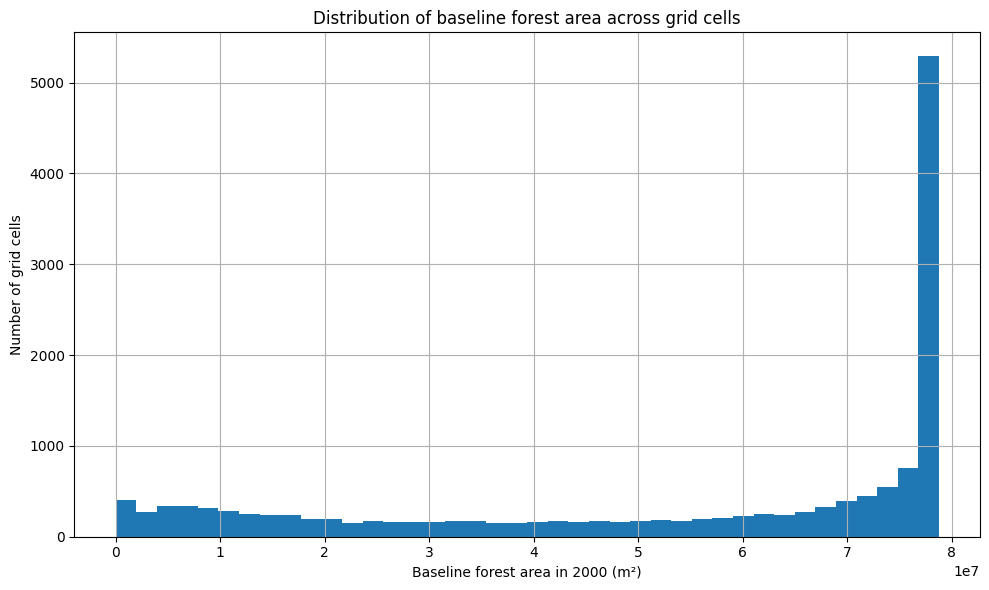

In [34]:
plt.figure()
df_wide["base_m2"].plot(kind="hist", bins=40)
plt.xlabel("Baseline forest area in 2000 (m²)")
plt.ylabel("Number of grid cells")
plt.title("Distribution of baseline forest area across grid cells")
save_fig(FIG_DIR / "01_hist_base_m2.png")
plt.show()

## Descriptive graph 2 — annual total forest loss

Saved figure: C:\Users\cpedr\OneDrive - Hertie School\PhD\Paper 2\paper2\outputs\figures\01_annual_total_loss.png


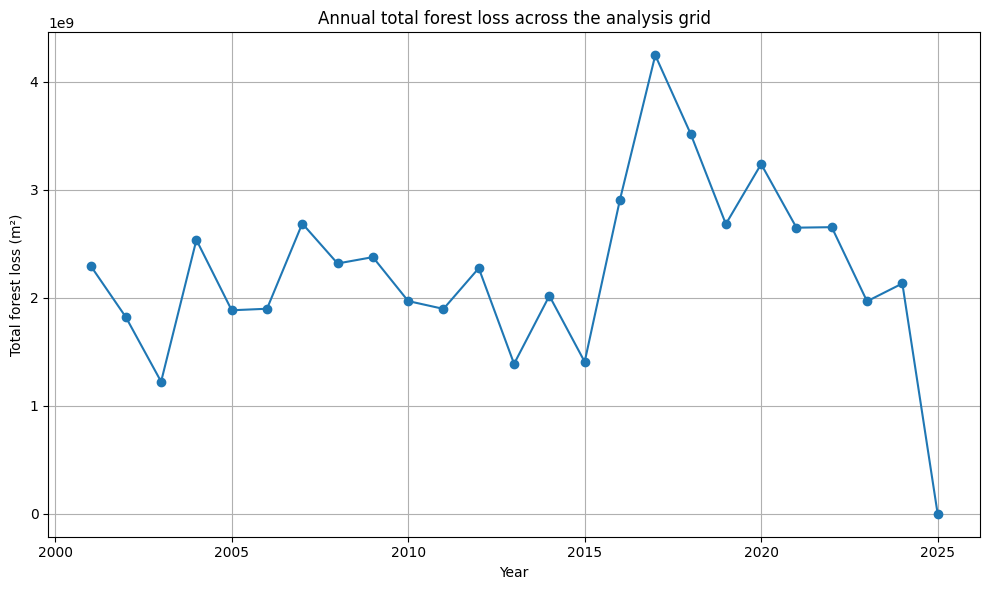

In [35]:
annual_loss = (
    df_long.groupby("year", as_index=False)["loss_m2"]
    .sum()
    .sort_values("year")
)

plt.figure()
plt.plot(annual_loss["year"], annual_loss["loss_m2"], marker="o")
plt.xlabel("Year")
plt.ylabel("Total forest loss (m²)")
plt.title("Annual total forest loss across the analysis grid")
save_fig(FIG_DIR / "01_annual_total_loss.png")
plt.show()

annual_loss.to_csv(TABLE_DIR / "01_annual_total_loss.csv", index=False)

## Descriptive map 1 — baseline forest area

This map joins the grid geometry to the wide panel and colors cells by baseline forest area.

Saved map: C:\Users\cpedr\OneDrive - Hertie School\PhD\Paper 2\paper2\outputs\maps\01_map_base_m2.png


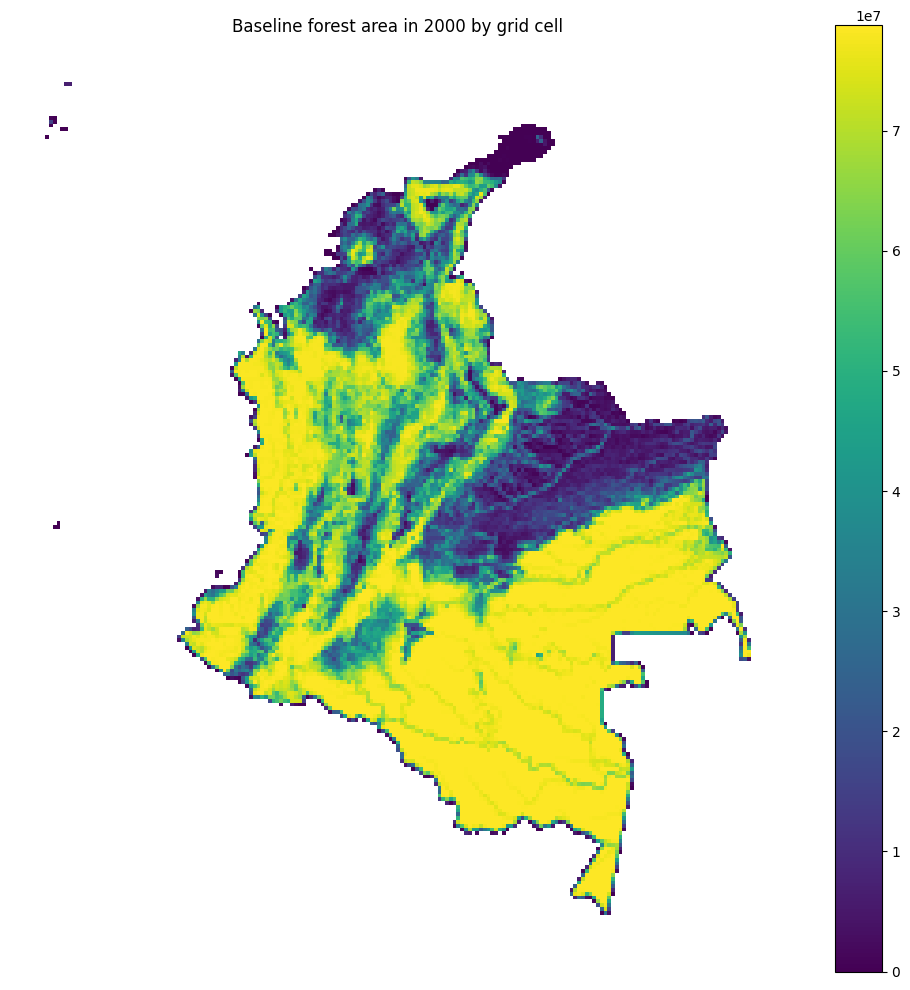

In [36]:
map_df = grid_gdf[[GRID_ID_COL, "geometry"]].merge(df_wide[[GRID_ID_COL, "base_m2"]], on=GRID_ID_COL, how="left")

fig, ax = plt.subplots(1, 1, figsize=(10, 10))
map_df.plot(column="base_m2", ax=ax, legend=True)
ax.set_title("Baseline forest area in 2000 by grid cell")
ax.set_axis_off()
fig.tight_layout()
fig.savefig(MAP_DIR / "01_map_base_m2.png", dpi=200, bbox_inches="tight")
print("Saved map:", MAP_DIR / "01_map_base_m2.png")
plt.show()

## Descriptive map 2 — cumulative forest loss over the study period

Saved map: C:\Users\cpedr\OneDrive - Hertie School\PhD\Paper 2\paper2\outputs\maps\01_map_cumulative_loss.png


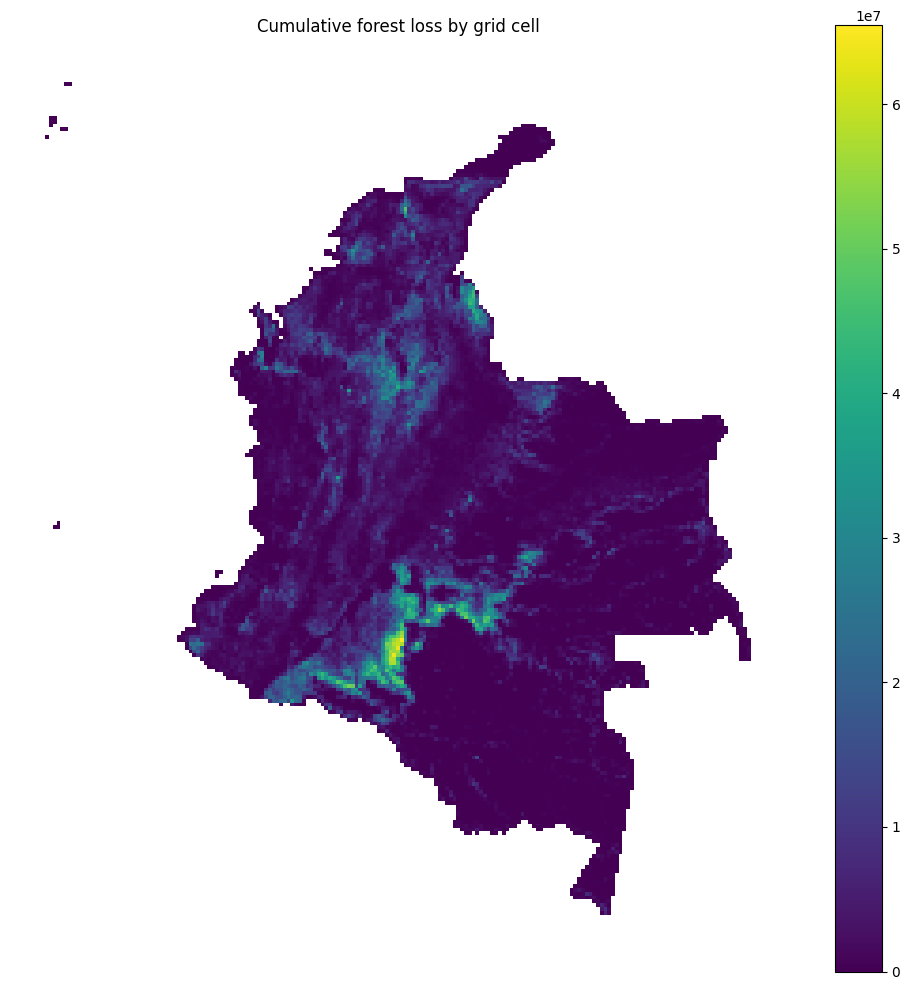

In [37]:
loss_cols = [c for c in df_wide.columns if c.startswith("loss_") and c.endswith("_m2")]
df_wide["loss_total_m2"] = df_wide[loss_cols].sum(axis=1)

map_df2 = grid_gdf[[GRID_ID_COL, "geometry"]].merge(
    df_wide[[GRID_ID_COL, "loss_total_m2"]],
    on=GRID_ID_COL,
    how="left"
)

fig, ax = plt.subplots(1, 1, figsize=(10, 10))
map_df2.plot(column="loss_total_m2", ax=ax, legend=True)
ax.set_title("Cumulative forest loss by grid cell")
ax.set_axis_off()
fig.tight_layout()
fig.savefig(MAP_DIR / "01_map_cumulative_loss.png", dpi=200, bbox_inches="tight")
print("Saved map:", MAP_DIR / "01_map_cumulative_loss.png")
plt.show()

In [50]:
import re
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib import colors, cm
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

LAST_AVAILABLE_LOSS_YEAR = 2024   # exclude 2025 for now
USE_ASINH_FOR_COLORS = True       # affects map colors only
HIST_BIN_METHOD = "quantile"      # "quantile" or an int like 12

# ------------------------------------------------------------
# Detect yearly loss columns that are actually usable
# ------------------------------------------------------------
loss_year_cols = []
for c in df_wide.columns:
    m = re.fullmatch(r"loss_(\d{4})_m2", c)
    if m:
        year = int(m.group(1))
        if year <= LAST_AVAILABLE_LOSS_YEAR:
            loss_year_cols.append((year, c))

loss_year_cols = sorted(loss_year_cols)
available_loss_years = [y for y, _ in loss_year_cols]
loss_cols = [c for _, c in loss_year_cols]

if not loss_cols:
    raise ValueError("No yearly loss columns found in df_wide.")

print("Available loss years:", available_loss_years[0], "to", available_loss_years[-1])
print("Number of yearly loss columns:", len(loss_cols))

# ------------------------------------------------------------
# Build loss summary variables
# ------------------------------------------------------------
loss_df = df_wide[[GRID_ID_COL] + loss_cols].copy()
loss_df[loss_cols] = loss_df[loss_cols].fillna(0)

loss_df["cum_loss_m2"] = loss_df[loss_cols].sum(axis=1)
loss_df["avg_annual_loss_m2"] = loss_df["cum_loss_m2"] / len(loss_cols)

loss_df["cum_loss_ha"] = loss_df["cum_loss_m2"] / 10000
loss_df["avg_annual_loss_ha"] = loss_df["avg_annual_loss_m2"] / 10000

# geometry + summary values
avg_loss_map_df = grid_gdf[[GRID_ID_COL, "geometry"]].merge(
    loss_df[[GRID_ID_COL, "cum_loss_ha", "avg_annual_loss_ha"]],
    on=GRID_ID_COL,
    how="left"
)

# yearly geometry frame for the interactive map
yearly_loss_map_df = grid_gdf[[GRID_ID_COL, "geometry"]].merge(
    loss_df[[GRID_ID_COL] + loss_cols],
    on=GRID_ID_COL,
    how="left"
)

for year, col in loss_year_cols:
    yearly_loss_map_df[f"loss_{year}_ha"] = yearly_loss_map_df[col].fillna(0) / 10000

Available loss years: 2001 to 2024
Number of yearly loss columns: 24


## Descriptive map 3 — average yearly forest loss over the study period

Saved map: C:\Users\cpedr\OneDrive - Hertie School\PhD\Paper 2\paper2\outputs\maps\01_map_avg_annual_loss_with_hist.png


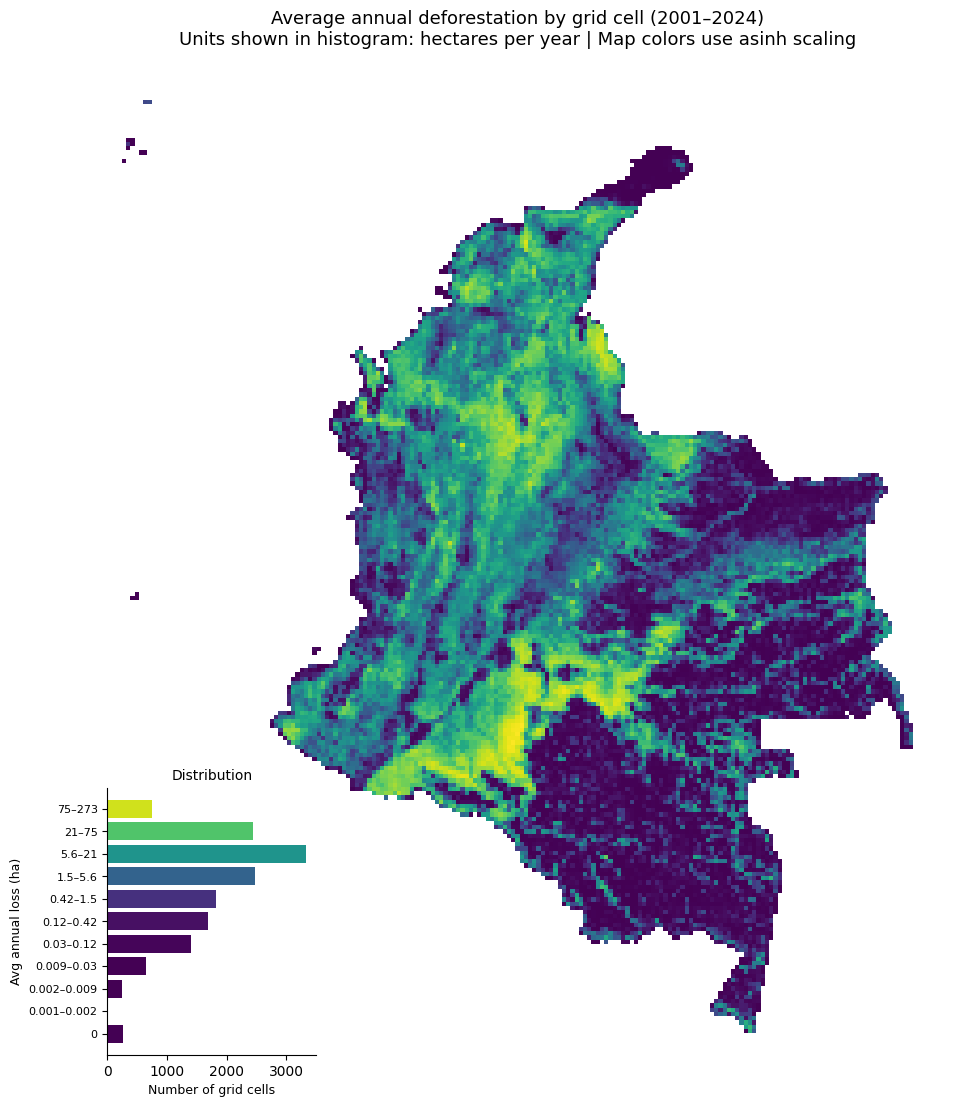

In [56]:
plt.close("all")

AVG_COL_RAW = "avg_annual_loss_ha"
AVG_COL_COLOR = "_avg_annual_loss_color"

plot_df = avg_loss_map_df.copy()
plot_df[AVG_COL_RAW] = plot_df[AVG_COL_RAW].fillna(0)

if USE_ASINH_FOR_COLORS:
    plot_df[AVG_COL_COLOR] = np.arcsinh(plot_df[AVG_COL_RAW].clip(lower=0))
    color_note = "Map colors use asinh scaling"
else:
    plot_df[AVG_COL_COLOR] = plot_df[AVG_COL_RAW].clip(lower=0)
    color_note = "Map colors use raw values"

# color setup
cmap = plt.cm.viridis
norm = colors.Normalize(
    vmin=float(plot_df[AVG_COL_COLOR].min()),
    vmax=float(plot_df[AVG_COL_COLOR].max())
)

# ------------------------------------------------------------
# Create fresh figure and main map axis
# ------------------------------------------------------------
fig, ax = plt.subplots(1, 1, figsize=(11, 11))

plot_df.plot(
    column=AVG_COL_COLOR,
    ax=ax,
    cmap="viridis",
    linewidth=0,
    legend=False,
    missing_kwds={"color": "lightgrey"}
)

ax.set_title(
    f"Average annual deforestation by grid cell ({available_loss_years[0]}–{available_loss_years[-1]})\n"
    f"Units shown in histogram: hectares per year | {color_note}",
    fontsize=13
)
ax.set_axis_off()

# ------------------------------------------------------------
# Histogram based on RAW values (ha), not transformed values
# ------------------------------------------------------------
hist_values = plot_df[AVG_COL_RAW].fillna(0).to_numpy()

HIST_BIN_STYLE = "log"      # "equal" or "log"
HIST_N_BINS = 10            # positive-value bins only
SHOW_ZERO_BIN = True

# inset size / position
HIST_WIDTH = "24%"
HIST_HEIGHT = "26%"
HIST_LOC = "lower left"
HIST_BORDERPAD = 1.8

positive_vals = hist_values[hist_values > 0]
zero_count = int((hist_values == 0).sum())

if HIST_BIN_STYLE == "equal":
    if len(positive_vals) == 0:
        pos_edges = np.array([0, 1])
    else:
        pos_edges = np.histogram_bin_edges(positive_vals, bins=HIST_N_BINS)

elif HIST_BIN_STYLE == "log":
    if len(positive_vals) == 0:
        pos_edges = np.array([0, 1])
    else:
        vmin = positive_vals.min()
        vmax = positive_vals.max()
        pos_edges = np.geomspace(vmin, vmax, HIST_N_BINS + 1)
        pos_edges = np.unique(pos_edges)

        if len(pos_edges) < 3:
            pos_edges = np.histogram_bin_edges(positive_vals, bins=HIST_N_BINS)
else:
    raise ValueError("HIST_BIN_STYLE must be 'equal' or 'log'")

pos_counts, pos_edges = np.histogram(positive_vals, bins=pos_edges)
pos_centers = (pos_edges[:-1] + pos_edges[1:]) / 2

def fmt_bin_value(x):
    if x == 0:
        return "0"
    elif x < 0.01:
        return f"{x:.3f}"
    elif x < 0.1:
        return f"{x:.2f}"
    elif x < 1:
        return f"{x:.2f}"
    elif x < 10:
        return f"{x:.1f}"
    else:
        return f"{x:.0f}"

pos_labels = [
    f"{fmt_bin_value(pos_edges[i])}–{fmt_bin_value(pos_edges[i+1])}"
    for i in range(len(pos_edges) - 1)
]

if USE_ASINH_FOR_COLORS:
    pos_color_values = np.arcsinh(np.clip(pos_centers, a_min=0, a_max=None))
    zero_color_value = np.arcsinh(0.0)
else:
    pos_color_values = np.clip(pos_centers, a_min=0, a_max=None)
    zero_color_value = 0.0

pos_bar_colors = cmap(norm(pos_color_values))

hist_counts = pos_counts.tolist()
hist_labels = pos_labels.copy()
hist_colors = list(pos_bar_colors)

if SHOW_ZERO_BIN:
    hist_counts = [zero_count] + hist_counts
    hist_labels = ["0"] + hist_labels
    hist_colors = [cmap(norm(zero_color_value))] + hist_colors

# ------------------------------------------------------------
# Plot inset histogram
# ------------------------------------------------------------
ax_hist = inset_axes(
    ax,
    width=HIST_WIDTH,
    height=HIST_HEIGHT,
    loc=HIST_LOC,
    borderpad=HIST_BORDERPAD
)

ypos = np.arange(len(hist_counts))
ax_hist.barh(ypos, hist_counts, color=hist_colors, edgecolor="none")

ax_hist.set_yticks(ypos)
ax_hist.set_yticklabels(hist_labels, fontsize=8)
ax_hist.set_xlabel("Number of grid cells", fontsize=9)
ax_hist.set_ylabel("Avg annual loss (ha)", fontsize=9)
ax_hist.set_title("Distribution", fontsize=10)

ax_hist.grid(False)

for spine in ["top", "right"]:
    ax_hist.spines[spine].set_visible(False)

ax_hist.set_facecolor("white")

fig.tight_layout()

avg_loss_map_path = MAP_DIR / "01_map_avg_annual_loss_with_hist.png"
fig.savefig(avg_loss_map_path, dpi=220, bbox_inches="tight")
print("Saved map:", avg_loss_map_path)
plt.show()

## Descriptive map 4 — interactive map for yearly forest loss over the study period

In [66]:
import folium
import branca.colormap as bcm
from branca.element import Element
import uuid

# Use WGS84 for folium
yearly_loss_map_wgs84 = yearly_loss_map_df.to_crs(4326).copy()

INTERACTIVE_SIMPLIFY_TOL = None
if INTERACTIVE_SIMPLIFY_TOL is not None:
    yearly_loss_map_wgs84["geometry"] = yearly_loss_map_wgs84.geometry.simplify(
        INTERACTIVE_SIMPLIFY_TOL, preserve_topology=True
    )

center = [
    yearly_loss_map_wgs84.unary_union.centroid.y,
    yearly_loss_map_wgs84.unary_union.centroid.x
]

def build_year_dropdown_map(use_asinh_for_colors=True):
    m = folium.Map(location=center, zoom_start=5, tiles=None)

    folium.TileLayer("CartoDB positron", name="Basemap", control=False).add_to(m)

    all_vals = []
    for year in available_loss_years:
        col = f"loss_{year}_ha"
        vals = yearly_loss_map_wgs84[col].fillna(0).clip(lower=0).to_numpy()
        if use_asinh_for_colors:
            vals = np.arcsinh(vals)
        all_vals.extend(vals.tolist())

    vmin = float(np.min(all_vals))
    vmax = float(np.max(all_vals))
    if vmax <= vmin:
        vmax = vmin + 1e-9

    cmap = bcm.LinearColormap(
        colors=[
            "#440154", "#482878", "#3e4989", "#31688e", "#26828e",
            "#1f9e89", "#35b779", "#6ece58", "#b5de2b", "#fde725"
        ],
        vmin=vmin,
        vmax=vmax
    )
    cmap.caption = (
        "Forest loss (ha), colors use asinh scaling"
        if use_asinh_for_colors
        else "Forest loss (ha)"
    )

    year_layers = {}
    default_year = str(available_loss_years[0])

    for i, year in enumerate(available_loss_years):
        value_col = f"loss_{year}_ha"
        gdf_plot = yearly_loss_map_wgs84[[GRID_ID_COL, "geometry", value_col]].copy()
        gdf_plot[value_col] = gdf_plot[value_col].fillna(0)

        if use_asinh_for_colors:
            gdf_plot["_color_value"] = np.arcsinh(gdf_plot[value_col].clip(lower=0))
        else:
            gdf_plot["_color_value"] = gdf_plot[value_col].clip(lower=0)

        fg = folium.FeatureGroup(
            name=str(year),
            show=(i == 0),
            control=False
        )

        folium.GeoJson(
            data=gdf_plot.to_json(),
            style_function=lambda feature, cm=cmap: {
                "fillColor": cm(feature["properties"]["_color_value"]),
                "color": "transparent",
                "weight": 0,
                "fillOpacity": 0.75,
            },
            highlight_function=lambda feature: {
                "fillOpacity": 0.95,
                "color": "black",
                "weight": 0.4,
            },
            tooltip=folium.GeoJsonTooltip(
                fields=[GRID_ID_COL, value_col],
                aliases=["Cell ID", f"Loss in {year} (ha)"],
                localize=True,
                sticky=False,
            ),
            smooth_factor=0.2,
        ).add_to(fg)

        fg.add_to(m)
        year_layers[str(year)] = fg

    cmap.add_to(m)

    # Dropdown HTML
    select_id = f"year_select_{uuid.uuid4().hex[:8]}"

    options_html = "\n".join(
        [
            f'<option value="{year}" {"selected" if str(year) == default_year else ""}>{year}</option>'
            for year in available_loss_years
        ]
    )

    dropdown_html = f"""
    <div style="
        position: fixed;
        top: 10px;
        right: 10px;
        z-index: 9999;
        background: white;
        padding: 8px 10px;
        border: 1px solid #bbb;
        border-radius: 4px;
        box-shadow: 0 1px 4px rgba(0,0,0,0.2);
        font-size: 14px;
    ">
        <label for="{select_id}" style="display:block; margin-bottom:4px;"><b>Year</b></label>
        <select id="{select_id}" style="width: 90px;">
            {options_html}
        </select>
    </div>
    """

    m.get_root().html.add_child(Element(dropdown_html))

    layer_js = ",\n".join(
        [f'"{year}": {layer.get_name()}' for year, layer in year_layers.items()]
    )

    script_html = f"""
    <script>
    window.addEventListener("load", function() {{
        var map = {m.get_name()};
        var yearLayers = {{
            {layer_js}
        }};
        var currentYear = "{default_year}";
        var select = document.getElementById("{select_id}");

        function showYear(year) {{
            Object.keys(yearLayers).forEach(function(y) {{
                try {{
                    if (map.hasLayer(yearLayers[y])) {{
                        map.removeLayer(yearLayers[y]);
                    }}
                }} catch (err) {{
                    console.log("Layer removal error for year", y, err);
                }}
            }});

            try {{
                if (yearLayers[year]) {{
                    map.addLayer(yearLayers[year]);
                    currentYear = year;
                }}
            }} catch (err) {{
                console.log("Layer add error for year", year, err);
            }}
        }}

        if (select) {{
            select.addEventListener("change", function(e) {{
                showYear(e.target.value);
            }});
        }}

        showYear(currentYear);
    }});
    </script>
    """

    m.get_root().html.add_child(Element(script_html))
    return m

year_dropdown_map = build_year_dropdown_map(use_asinh_for_colors=USE_ASINH_FOR_COLORS)

interactive_map_path = MAP_DIR / "01_interactive_yearly_loss_map_dropdown.html"
year_dropdown_map.save(str(interactive_map_path))
print("Saved interactive map:", interactive_map_path)

Saved interactive map: C:\Users\cpedr\OneDrive - Hertie School\PhD\Paper 2\paper2\outputs\maps\01_interactive_yearly_loss_map_dropdown.html


## Final notes

At the end of this notebook, the key outputs for the next steps are:

- `data/intermediate/panel_raw_wide.parquet`
- `data/intermediate/panel_raw_long.parquet`
- `data/intermediate/grid_geometry.geojson`

The next notebook can now define treatment timing and build the staggered-adoption structure on top of this cleaned grid-year panel.